In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# load minist dataset fromtensorflow

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


## Load dataset

In [13]:
(x_train,y_train),(x_test,y_test)=mnist.load_data()

## sample images

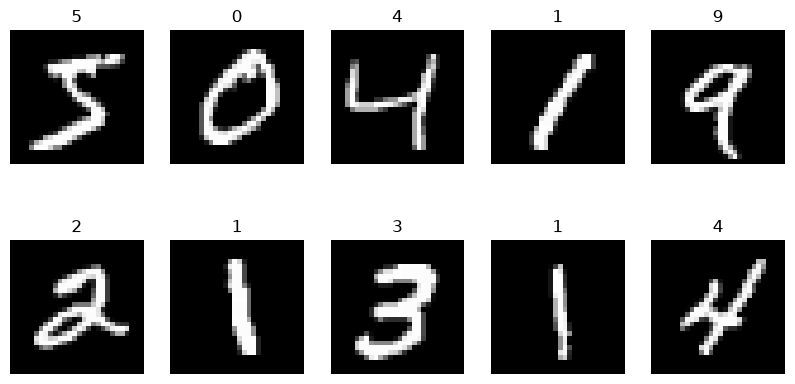

In [14]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i],cmap='gray')
    plt.title(y_train[i])
    plt.axis("off")

plt.savefig("mnist_sampple.png")


## Normalize image

In [15]:
x_train=x_train/255.0
x_test=x_test/255.0

## flatten images


In [16]:
# check before
print(x_train.shape)

(60000, 28, 28)


In [17]:
x_train=x_train.reshape(60000,784)
x_test=x_test.reshape(10000,784)

print(x_train.shape)

(60000, 784)


## one hot encoded

In [18]:
y_train=to_categorical(y_train)
y_test=to_categorical(y_test)

# Build RELU Model 1

In [19]:
Relu_model=Sequential() # sequential()-->below three layers are insequence form connect each other

Relu_model.add(Dense(128,activation='relu',input_shape=(784,)))
Relu_model.add(Dense(64,activation='relu'))
Relu_model.add(Dense(10,activation='softmax'))

c:\Users\Administrator\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
# Configure the model before training
Relu_model.compile(

    optimizer='adam',    # Controls how the model learns and updates its weights

    loss='categorical_crossentropy',   # Measures how wrong the model's predictions are

    metrics=['accuracy']    # Tracks the model's accuracy after each training epoch
)

## Train relu model

In [21]:
history_model=Relu_model.fit(
    x_train,
    y_train,
    epochs=10,   #we have 60k images they complete all images on by one image1 to image 60k so this is 1 epoch
    batch_size=32, #total iamges for tarining 60k so divide by 32 ther is 1875 batches
    validation_split=0.2
)
# output :

# what and why this 1500/1500 so :
# batch_size =32
# total image= 60000 --> 20% for validation so ---> 48000 training image
# now divide by 2 so: 48000/2=1500 batches

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9227 - loss: 0.2692 - val_accuracy: 0.9476 - val_loss: 0.1700
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9644 - loss: 0.1156 - val_accuracy: 0.9656 - val_loss: 0.1161
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9760 - loss: 0.0785 - val_accuracy: 0.9697 - val_loss: 0.1036
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9805 - loss: 0.0615 - val_accuracy: 0.9714 - val_loss: 0.0970
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9851 - loss: 0.0468 - val_accuracy: 0.9720 - val_loss: 0.0982
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9881 - loss: 0.0374 - val_accuracy: 0.9722 - val_loss: 0.1061
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9892 - loss: 0.0326 - val_accuracy: 0.9784 - val_loss: 0.0871
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9918 - loss: 0.0248 - 

# Build Sigmoid Model 2

In [22]:
sigmoi_model=Sequential()

sigmoi_model.add(Dense(128,activation='sigmoid',input_shape=(784,)))
sigmoi_model.add(Dense(64, activation='sigmoid'))
sigmoi_model.add(Dense(10,activation='softmax'))

In [23]:
sigmoi_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
# compile() must be called before fit().
# optimizer decides how the model learns.
# loss measures prediction error.
# accuracy measures how many predictions are correct.
# categorical_crossentropy is used with one-hot encoded labels.

## train model

In [24]:
history_sigmoid=sigmoi_model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8711 - loss: 0.5166 - val_accuracy: 0.9337 - val_loss: 0.2323
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9419 - loss: 0.1996 - val_accuracy: 0.9539 - val_loss: 0.1615
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9589 - loss: 0.1401 - val_accuracy: 0.9613 - val_loss: 0.1337
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9687 - loss: 0.1057 - val_accuracy: 0.9667 - val_loss: 0.1126
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9759 - loss: 0.0831 - val_accuracy: 0.9672 - val_loss: 0.1087
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9803 - loss: 0.0653 - val_accuracy: 0.9711 - val_loss: 0.0953
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9846 - loss: 0.0531 - val_accuracy: 0.9709 - val_loss: 0.0945
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9879 - loss: 0.0425 - 

In [25]:
relu_loss,relu_accuracy=Relu_model.evaluate(x_test,y_test)

print("Relu Accuracy:",relu_accuracy)
print("Relu Loss:",relu_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9779 - loss: 0.0871
Relu Accuracy: 0.9779000282287598
Relu Loss: 0.08708716183900833


In [26]:
sigmoid_loss,sigmoid_accuracy=sigmoi_model.evaluate(x_test,y_test)

print("sigmoid Accuracy:",sigmoid_accuracy)
print("sigmoid Loss:",sigmoid_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9759 - loss: 0.0779
sigmoid Accuracy: 0.9758999943733215
sigmoid Loss: 0.07785236835479736


In [30]:
print(history_model.history['accuracy'])

[0.9227291941642761, 0.9644166827201843, 0.9760416746139526, 0.9805416464805603, 0.9850624799728394, 0.9881458282470703, 0.989229142665863, 0.9918333292007446, 0.991895854473114, 0.9927083253860474]


# plot Accuracy (Relu model)

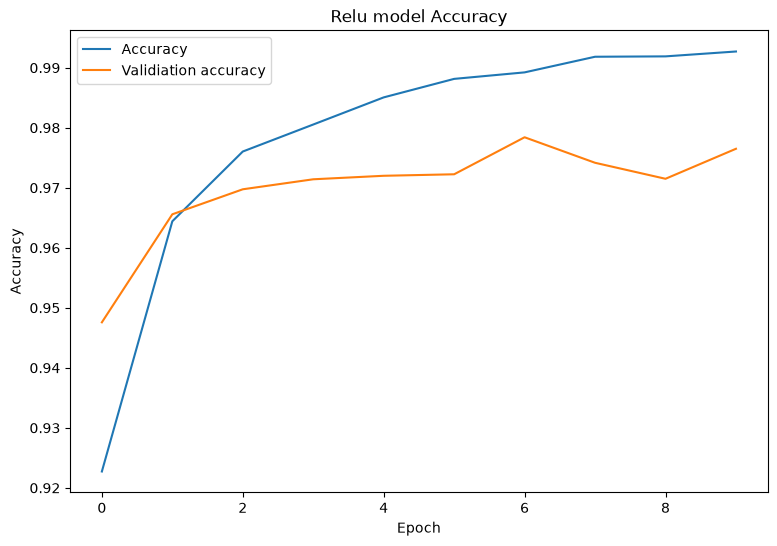

In [33]:
plt.figure(figsize=(9,6))

plt.plot(history_model.history['accuracy'],label='Accuracy')
plt.plot(history_model.history['val_accuracy'],label='Validiation accuracy')

plt.title("Relu model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.savefig("Relu model Accuracy Graph.png")

## plot loss

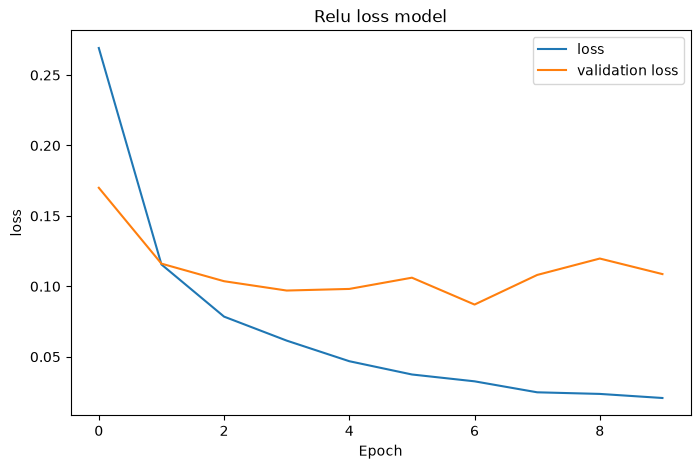

In [34]:
plt.figure(figsize=(8,5))

plt.plot(history_model.history['loss'],label='loss')
plt.plot(history_model.history['val_loss'],label='validation loss')

plt.title("Relu loss model")
plt.xlabel("Epoch")
plt.ylabel("loss")
plt.legend()

plt.savefig("Relu model loss graph.png")

# Sigmoid mdel Accuracy plot

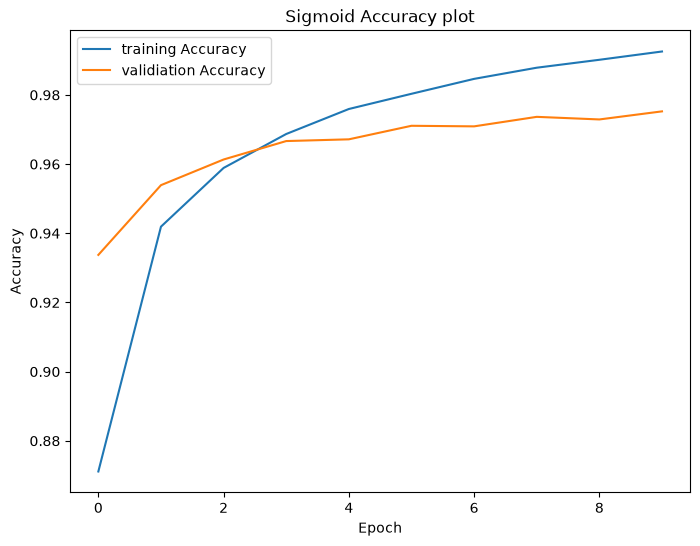

In [35]:
plt.figure(figsize=(8,6))

plt.plot(history_sigmoid.history['accuracy'],label='training Accuracy')
plt.plot(history_sigmoid.history['val_accuracy'],label='validiation Accuracy')

plt.title("Sigmoid Accuracy plot")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.savefig("Sigmoid Accuracy plot.png")

# sigmoid model loss plot

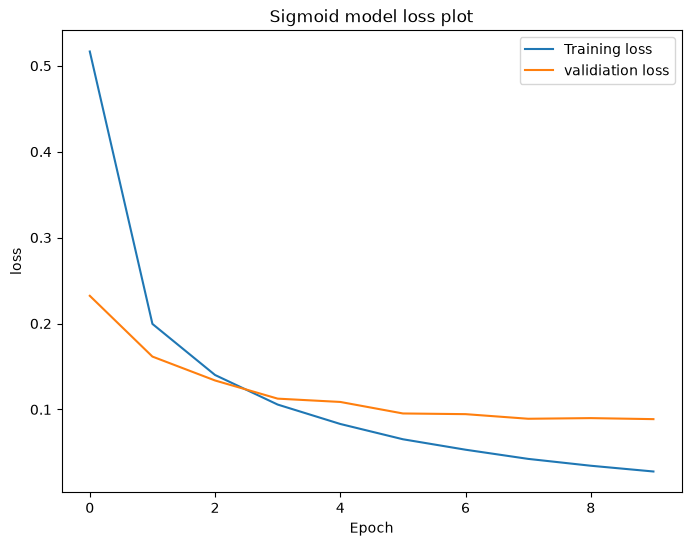

In [37]:
plt.figure(figsize=(8,6))

plt.plot(history_sigmoid.history['loss'],label='Training loss')
plt.plot(history_sigmoid.history['val_loss'],label='validiation loss')

plt.title("Sigmoid model loss plot")
plt.xlabel("Epoch")
plt.ylabel("loss")
plt.legend()

plt.savefig("Sigmoid model loss plot.png")

# compare results

In [42]:
print('ReLU Accuracy:',relu_accuracy*100)
print('sigmoid_accuracy:',sigmoid_accuracy*100)

print('Relu loss:',relu_loss*100)
print('sigmoid_loss:',sigmoid_loss*100)

ReLU Accuracy: 97.79000282287598
sigmoid_accuracy: 97.58999943733215
Relu loss: 8.708716183900833
sigmoid_loss: 7.785236835479736


# Predict image

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
predicted: 9
Actual: 9


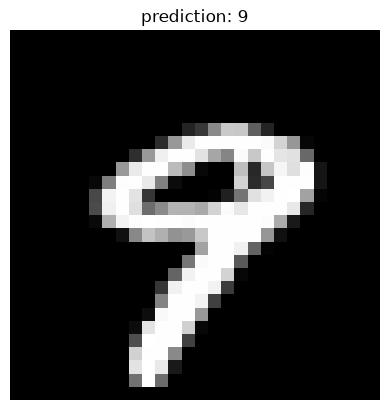

In [44]:
prediction=Relu_model.predict(x_test)

predicted_label=np.argmax(prediction[9])
true_label=np.argmax(y_test[9])

print("predicted:",predicted_label)
print("Actual:",true_label)

plt.imshow(x_test[9].reshape(28,28),cmap='gray')
plt.title('prediction: {}'.format(predicted_label))
plt.axis("off")

plt.savefig("image predict.png")